In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
from importlib import reload
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

In [3]:
from pathlib import Path

FIG_SAVE_PATH = Path("../results/figures/extra/ego_action")
FIG_SAVE_PATH.mkdir(parents=True, exist_ok=True)

## Example Cells

In [4]:
from GridMaze.analysis.core import get_clusters as gc

example_clusters = [
    "m6.2022-07-02.maze_cluster89",  # left pre
    "m6.2022-07-02.maze_cluster60",  # right pre
    "m6.2022-07-01.maze_cluster116",  # left on
    "m8.2022-07-01.maze_cluster53",  # right on
    "m3.2022-07-15.maze_cluster105",  # left post
    "m8.2022-06-28.maze_cluster26",  # right post
]

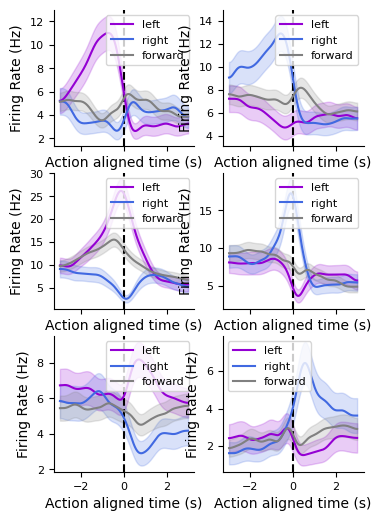

In [26]:
f, axes = plt.subplots(3, 2, figsize=(4, 6), clear=True, sharex=True)
for cluster, ax in zip(example_clusters, axes.flatten()):
    Cluster = gc.get_cluster(cluster)
    Cluster.plot_tuning(
        feature="actions",
        feature_kwargs={
            "concise": True,
            "action_type": "all",
            "smooth_SD": 14,
            "colors": ["darkviolet", "royalblue", "grey"],
        },
        ax=ax,
    )
f.savefig(FIG_SAVE_PATH / "example_ego_action_tunned_cells.pdf")

## Population Tuning

In [6]:
from GridMaze.analysis.egocentric_action import population_tuning as pt

In [7]:
tuning_df, metrics_df = pt.get_population_egocentric_action_tuning()

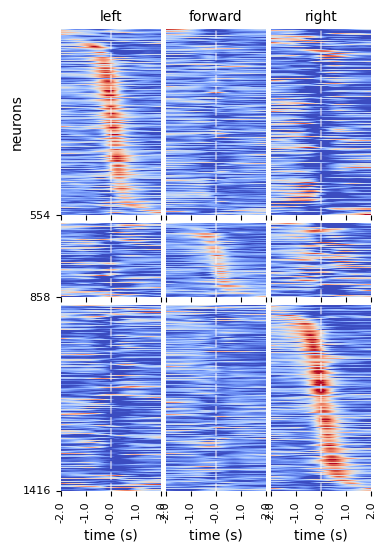

In [27]:
reload(pt)
f, axes = plt.subplots(3, 3, figsize=(4, 6), height_ratios=[1, 0.4, 1], sharex=True)
pt.plot_egocentric_action_tuning_heatmap(tuning_df, metrics_df, axes=axes, f=f)
f.savefig(FIG_SAVE_PATH / "population_ego_action_tuning.pdf")

## Population Dynamics

In [10]:
from GridMaze.analysis.egocentric_action import dynamics as edy

In [12]:
reload(edy)
activity_df, metrics_df = edy.get_population_tuning_df()

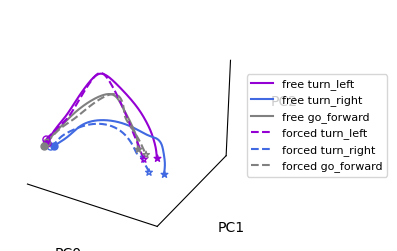

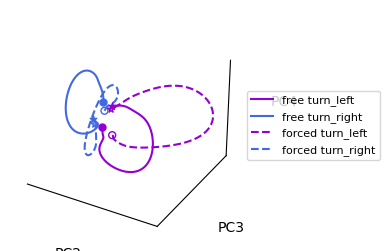

In [25]:
reload(edy)
PC_set_1 = (0, 1, 2)
f1, ax = edy._init_3D_plot(PC_set_1, figsize=(3, 3))
edy.PC_plot(activity_df, metrics_df, PCs=PC_set_1, actions=["turn_left", "turn_right", "go_forward"], f=f1, ax=ax)

PC_set_2 = (2, 3, 4)
f2, ax = edy._init_3D_plot(PC_set_2, figsize=(3, 3))
edy.PC_plot(activity_df, metrics_df, PCs=PC_set_2, actions=["turn_left", "turn_right"], f=f2, ax=ax)

f1.savefig(FIG_SAVE_PATH / "population_ego_action_dynamics_PC012.pdf")
f2.savefig(FIG_SAVE_PATH / "population_ego_action_dynamics_PC234.pdf")